# Body Composition Analysis - Complete Implementation
This notebook implements Random Forest Regressor models to predict BFP changes, muscle mass changes, and definition scores at different time intervals (3, 6, 9, 12 months).

In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

# Load the data
try:
    df = pd.read_csv('fatLoss.csv')
    print('Dataset loaded successfully!')
except:
    print('Error loading dataset')
    exit()

print('Dataset Overview:')
print(df.head())
print('\nDataset Info:')
print(df.info())

Dataset loaded successfully!
Dataset Overview:
         exercise_name target_muscle_group      type  age gender  sets  reps  \
0  Barbell Bench Press               Chest  Compound   32      M     4    10   
1  Barbell Bench Press               Chest  Compound   28      F     3    12   
2  Barbell Bench Press               Chest  Compound   39      M     5     8   
3  Barbell Bench Press               Chest  Compound   35      F     4    10   
4  Barbell Bench Press               Chest  Compound   26      M     3    12   

   weight  frequency  protein  calories  sleep    experience  \
0      80          3      150      2800    7.5  Intermediate   
1      45          2      130      2600    7.2      Beginner   
2      90          4      170      3100    8.0      Advanced   
3      50          3      135      2700    7.4  Intermediate   
4      85          2      145      2750    7.6  Intermediate   

   genetic_advantage  actual_fat_loss  daily_deficit  current_weight  height  
0       

In [24]:
# Calculate BMR (Basal Metabolic Rate) using Mifflin-St Jeor Equation
df.loc[df['gender'] == 'M', 'BMR'] = (
    88.362
    + (13.397 * df.loc[df['gender'] == 'M', 'current_weight'])
    + (4.799 * df.loc[df['gender'] == 'M', 'height'])
    - (5.677 * df.loc[df['gender'] == 'M', 'age'])
)

df.loc[df['gender'] == 'F', 'BMR'] = (
    447.593
    + (9.247 * df.loc[df['gender'] == 'F', 'current_weight'])
    + (3.098 * df.loc[df['gender'] == 'F', 'height'])
    - (4.330 * df.loc[df['gender'] == 'F', 'age'])
)

# Generate initial BFP if not present
np.random.seed(42)  # For reproducibility
df['BFP'] = np.random.uniform(5, 50, size=len(df))

print('BMR and BFP calculated!')

BMR and BFP calculated!


In [25]:
# Feature Engineering - Calculate body composition metrics
def calculate_body_composition_features(df):
    """Calculate additional features for body composition prediction"""
    
    # BMI (Body Mass Index)
    df['BMI'] = df['current_weight'] / ((df['height'] / 100) ** 2)
    
    # Activity level (using 5 as default intensity)
    df['activity_level'] = df['frequency'] * 5
    
    # TDEE (Total Daily Energy Expenditure)
    df['TDEE'] = df['BMR'] * (1.2 + (df['activity_level'] * 0.1))
    
    # Estimated fat mass
    df['estimated_fat_mass'] = (df['BFP'] / 100) * df['current_weight']
    
    # Estimate muscle mass
    df['muscle_mass'] = df['current_weight'] - df['estimated_fat_mass']
    
    # Training intensity score
    df['training_intensity'] = (df['weight'] * df['sets'] * df['reps']) / df['current_weight']
    
    # Sleep quality factor
    df['sleep_quality'] = np.where(df['sleep'] >= 7.5, 1, df['sleep'] / 7.5)
    
    # Protein per kg body weight
    df['protein_per_kg'] = df['protein'] / df['current_weight']
    
    # Caloric deficit ratio
    df['deficit_ratio'] = df['daily_deficit'] / df['TDEE']
    
    return df

# Apply feature engineering
df = calculate_body_composition_features(df)
print('Feature engineering completed!')

Feature engineering completed!


In [26]:
# Generate target variables for BFP and muscle mass at different time intervals
np.random.seed(42)

# Calculate predicted weight after fat loss
df['predicted_weight_after_loss'] = df['current_weight'] - df['actual_fat_loss']

# Generate BFP at different months (decreasing over time)
# More aggressive fat loss in early months, slower later
df['bfp_at_3'] = df['BFP'] - np.random.uniform(2, 5, size=len(df))
df['bfp_at_6'] = df['bfp_at_3'] - np.random.uniform(1, 3, size=len(df))
df['bfp_at_9'] = df['bfp_at_6'] - np.random.uniform(0.5, 2, size=len(df))
df['bfp_at_12'] = df['bfp_at_9'] - np.random.uniform(0.5, 1.5, size=len(df))

# Ensure BFP doesn't go below realistic minimum (3% for men, 8% for women)
min_bfp = np.where(df['gender'] == 'M', 3, 8)
df['bfp_at_3'] = np.maximum(df['bfp_at_3'], min_bfp)
df['bfp_at_6'] = np.maximum(df['bfp_at_6'], min_bfp)
df['bfp_at_9'] = np.maximum(df['bfp_at_9'], min_bfp)
df['bfp_at_12'] = np.maximum(df['bfp_at_12'], min_bfp)

# Calculate muscle mass at different time intervals
# Assuming some muscle gain due to training
muscle_gain_factor = 1 + (df['training_intensity'] * 0.001)  # Small muscle gain

df['muscle_mass_at_3'] = (df['predicted_weight_after_loss'] * (1 - df['bfp_at_3']/100)) * muscle_gain_factor
df['muscle_mass_at_6'] = (df['predicted_weight_after_loss'] * (1 - df['bfp_at_6']/100)) * muscle_gain_factor
df['muscle_mass_at_9'] = (df['predicted_weight_after_loss'] * (1 - df['bfp_at_9']/100)) * muscle_gain_factor
df['muscle_mass_at_12'] = (df['predicted_weight_after_loss'] * (1 - df['bfp_at_12']/100)) * muscle_gain_factor

# Calculate definition scores (higher muscle mass + lower BFP = higher definition)
# Scale to 1-10 range
def calculate_definition(muscle_mass, bfp):
    # Higher muscle mass and lower BFP = better definition
    definition_raw = (muscle_mass / 10) * (50 - bfp) / 10
    # Scale to 1-10 range
    return np.clip(definition_raw / definition_raw.max() * 9 + 1, 1, 10)

df['definition_at_3'] = calculate_definition(df['muscle_mass_at_3'], df['bfp_at_3'])
df['definition_at_6'] = calculate_definition(df['muscle_mass_at_6'], df['bfp_at_6'])
df['definition_at_9'] = calculate_definition(df['muscle_mass_at_9'], df['bfp_at_9'])
df['definition_at_12'] = calculate_definition(df['muscle_mass_at_12'], df['bfp_at_12'])

print('Target variables generated for all time intervals!')
print(f'BFP range at 12 months: {df["bfp_at_12"].min():.1f}% - {df["bfp_at_12"].max():.1f}%')
print(f'Definition score range at 12 months: {df["definition_at_12"].min():.1f} - {df["definition_at_12"].max():.1f}')

Target variables generated for all time intervals!
BFP range at 12 months: 3.0% - 41.1%
Definition score range at 12 months: 1.8 - 10.0


In [27]:
# Prepare data for modeling
# Handle categorical variables
le_gender = LabelEncoder()
le_experience = LabelEncoder()
le_type = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['experience_encoded'] = le_experience.fit_transform(df['experience'])
df['type_encoded'] = le_type.fit_transform(df['type'])

# Define feature set
features = [
    'age', 'gender_encoded', 'current_weight', 'height', 'BMI',
    'sets', 'reps', 'weight', 'frequency', 'training_intensity',
    'protein', 'protein_per_kg', 'calories', 'sleep', 'sleep_quality',
    'experience_encoded', 'genetic_advantage', 'daily_deficit', 'deficit_ratio',
    'type_encoded', 'BFP', 'muscle_mass', 'TDEE', 'activity_level'
]

# Check if all features exist
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"Missing features: {missing_features}")
else:
    X = df[features]
    print(f"Feature matrix prepared with {len(features)} features")
    print(f"Dataset shape: {X.shape}")

Feature matrix prepared with 24 features
Dataset shape: (390, 24)


In [28]:
# Train Random Forest models for each time interval and metric
time_intervals = [3, 6, 9, 12]
metrics = ['bfp', 'muscle_mass', 'definition']

# Dictionary to store all models
models = {}
model_scores = {}

# Train models for each combination
for interval in time_intervals:
    models[interval] = {}
    model_scores[interval] = {}
    
    for metric in metrics:
        target_col = f'{metric}_at_{interval}'
        y = df[target_col]
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Train Random Forest model
        rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
        rf.fit(X_train, y_train)
        
        # Make predictions and evaluate
        y_pred = rf.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Store model and scores
        models[interval][metric] = rf
        model_scores[interval][metric] = {'mse': mse, 'r2': r2}
        
        print(f'{metric.upper()} at {interval} months - MSE: {mse:.3f}, R²: {r2:.3f}')

print('\nAll models trained successfully!')

BFP at 3 months - MSE: 0.054, R²: 1.000
MUSCLE_MASS at 3 months - MSE: 1.499, R²: 0.985
DEFINITION at 3 months - MSE: 0.035, R²: 0.992
BFP at 6 months - MSE: 0.509, R²: 0.996
MUSCLE_MASS at 6 months - MSE: 1.824, R²: 0.981
DEFINITION at 6 months - MSE: 0.053, R²: 0.988
BFP at 9 months - MSE: 0.604, R²: 0.995
MUSCLE_MASS at 9 months - MSE: 2.157, R²: 0.978
DEFINITION at 9 months - MSE: 0.085, R²: 0.980
BFP at 12 months - MSE: 0.654, R²: 0.995
MUSCLE_MASS at 12 months - MSE: 2.066, R²: 0.979
DEFINITION at 12 months - MSE: 0.104, R²: 0.976

All models trained successfully!


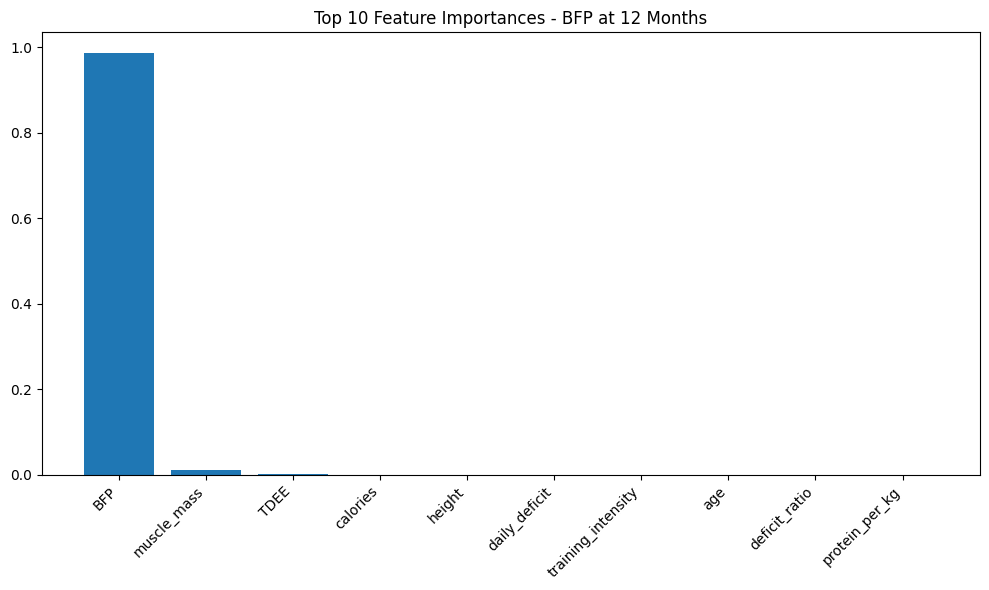

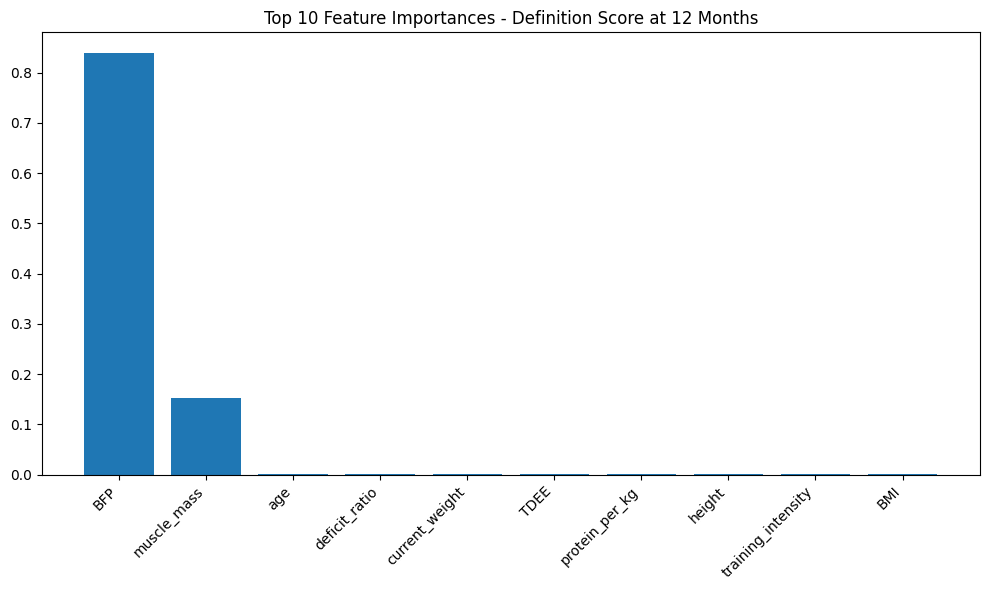

In [29]:
# Feature importance analysis
def plot_feature_importance(model, feature_names, title):
    """Plot feature importance for a given model"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]  # Top 10 features
    
    plt.figure(figsize=(10, 6))
    plt.title(f'Top 10 Feature Importances - {title}')
    plt.bar(range(10), importances[indices])
    plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Plot feature importance for BFP at 12 months (most important prediction)
plot_feature_importance(models[12]['bfp'], features, 'BFP at 12 Months')
plot_feature_importance(models[12]['definition'], features, 'Definition Score at 12 Months')

In [30]:
# Complete prediction function
def predict_body_composition_journey(user_data):
    """
    Predict complete body composition journey for a new user
    Returns predictions for BFP, muscle mass, and definition at 3, 6, 9, 12 months
    """
    
    # Create DataFrame from user data
    user_df = pd.DataFrame([user_data])
    
    # Calculate BMR
    if user_data['gender'] == 'M':
        bmr = (88.362 + (13.397 * user_data['current_weight']) + 
               (4.799 * user_data['height']) - (5.677 * user_data['age']))
    else:
        bmr = (447.593 + (9.247 * user_data['current_weight']) + 
               (3.098 * user_data['height']) - (4.330 * user_data['age']))
    
    user_df['BMR'] = bmr
    
    # Feature engineering for user data
    user_df['BMI'] = user_data['current_weight'] / ((user_data['height'] / 100) ** 2)
    user_df['activity_level'] = user_data['frequency'] * 5
    user_df['TDEE'] = bmr * (1.2 + (user_df['activity_level'] * 0.1))
    user_df['estimated_fat_mass'] = (user_data['BFP'] / 100) * user_data['current_weight']
    user_df['muscle_mass'] = user_data['current_weight'] - user_df['estimated_fat_mass']
    user_df['training_intensity'] = (user_data['weight'] * user_data['sets'] * user_data['reps']) / user_data['current_weight']
    user_df['sleep_quality'] = 1 if user_data['sleep'] >= 7.5 else user_data['sleep'] / 7.5
    user_df['protein_per_kg'] = user_data['protein'] / user_data['current_weight']
    user_df['deficit_ratio'] = user_data['daily_deficit'] / user_df['TDEE'].iloc[0]
    
    # Encode categorical variables
    user_df['gender_encoded'] = le_gender.transform([user_data['gender']])[0]
    user_df['experience_encoded'] = le_experience.transform([user_data['experience']])[0]
    user_df['type_encoded'] = le_type.transform([user_data['type']])[0]
    
    # Add initial values
    user_df['BFP'] = user_data['BFP']
    
    # Select features
    user_X = user_df[features]
    
    # Make predictions for all time intervals
    predictions = {}
    
    for interval in time_intervals:
        predictions[interval] = {}
        
        for metric in metrics:
            pred = models[interval][metric].predict(user_X)[0]
            predictions[interval][metric] = max(pred, 0)  # Ensure non-negative values
    
    return predictions

# Example usage with new user data
new_user = {
    'age': 28,
    'gender': 'M',
    'current_weight': 85,
    'height': 180,
    'sets': 4,
    'reps': 10,
    'weight': 80,
    'frequency': 4,
    'protein': 150,
    'calories': 2200,
    'sleep': 8.0,
    'experience': 'Intermediate',
    'genetic_advantage': 4,
    'daily_deficit': 500,
    'type': 'Compound',
    'BFP': 18.0  # Starting body fat percentage
}

# Get predictions
journey = predict_body_composition_journey(new_user)

# Display results
print('\n=== BODY COMPOSITION JOURNEY PREDICTION ===')
print(f'Starting Stats: Weight: {new_user["current_weight"]}kg, BFP: {new_user["BFP"]}%')
print('\nPredicted Progress:')

for interval in time_intervals:
    print(f'\nMonth {interval}:')
    print(f'  Body Fat: {journey[interval]["bfp"]:.1f}%')
    print(f'  Muscle Mass: {journey[interval]["muscle_mass"]:.1f}kg')
    print(f'  Definition Score: {journey[interval]["definition"]:.1f}/10')


=== BODY COMPOSITION JOURNEY PREDICTION ===
Starting Stats: Weight: 85kg, BFP: 18.0%

Predicted Progress:

Month 3:
  Body Fat: 15.2%
  Muscle Mass: 60.7kg
  Definition Score: 6.4/10

Month 6:
  Body Fat: 13.7%
  Muscle Mass: 62.6kg
  Definition Score: 6.6/10

Month 9:
  Body Fat: 12.2%
  Muscle Mass: 63.7kg
  Definition Score: 6.9/10

Month 12:
  Body Fat: 11.1%
  Muscle Mass: 64.0kg
  Definition Score: 7.0/10


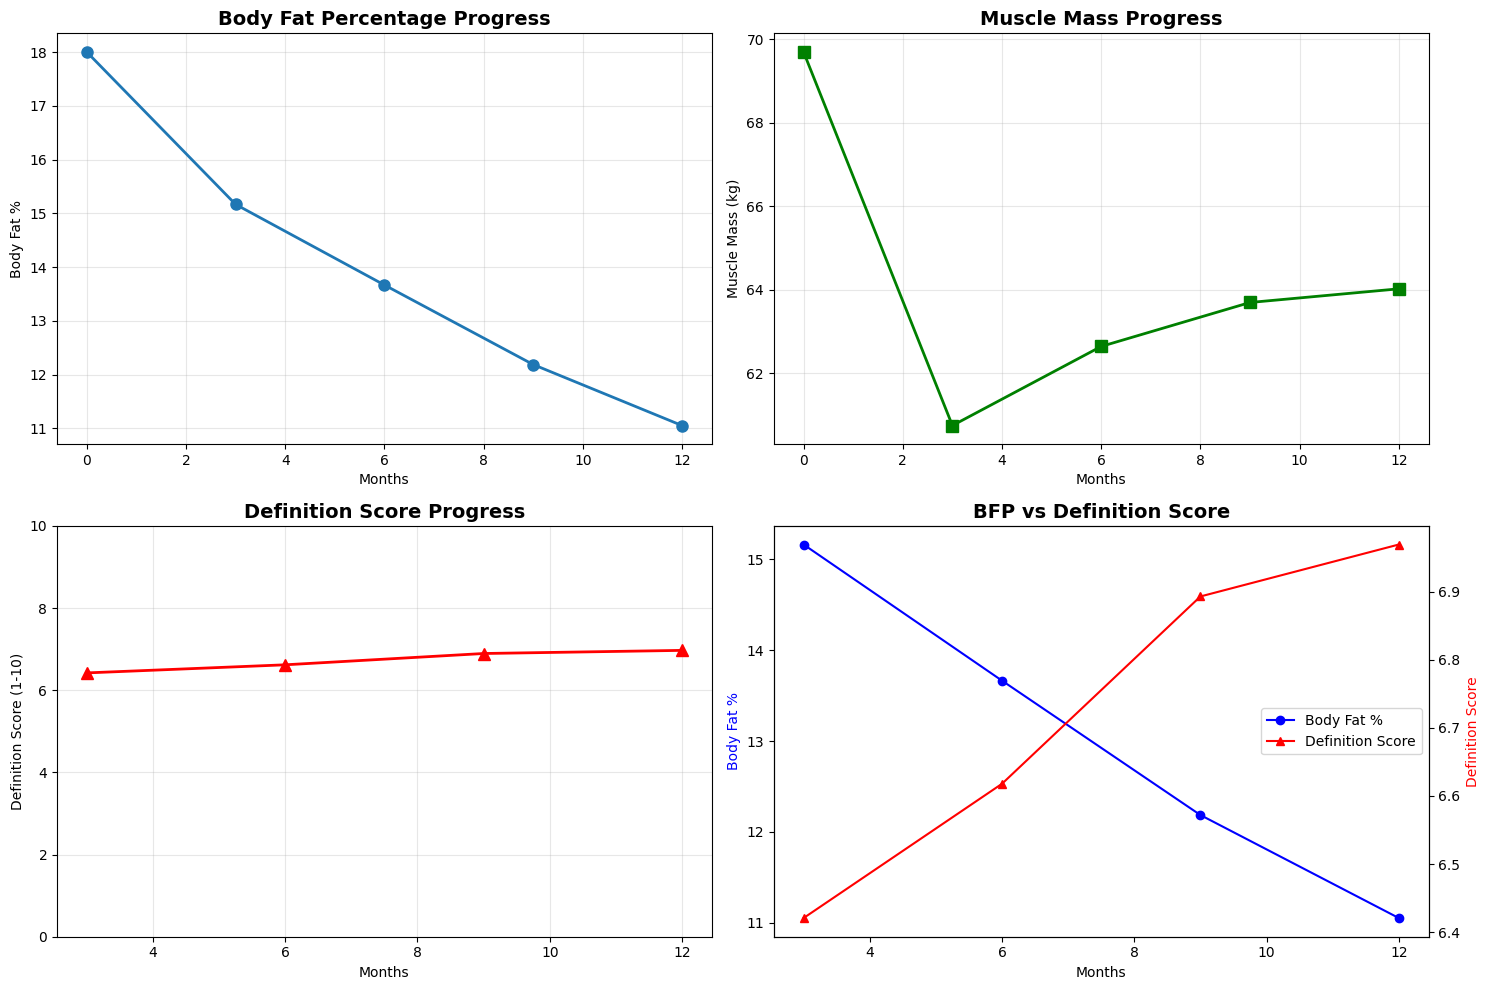

In [31]:
# Visualization of the journey
def plot_body_composition_journey(predictions, user_data):
    """Plot the predicted body composition journey"""
    
    months = list(predictions.keys())
    bfp_values = [predictions[m]['bfp'] for m in months]
    muscle_values = [predictions[m]['muscle_mass'] for m in months]
    definition_values = [predictions[m]['definition'] for m in months]
    
    # Add starting values
    months_with_start = [0] + months
    bfp_with_start = [user_data['BFP']] + bfp_values
    muscle_with_start = [user_data['current_weight'] - (user_data['BFP']/100 * user_data['current_weight'])] + muscle_values
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # BFP progression
    ax1.plot(months_with_start, bfp_with_start, marker='o', linewidth=2, markersize=8)
    ax1.set_title('Body Fat Percentage Progress', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Months')
    ax1.set_ylabel('Body Fat %')
    ax1.grid(True, alpha=0.3)
    
    # Muscle mass progression
    ax2.plot(months_with_start, muscle_with_start, marker='s', color='green', linewidth=2, markersize=8)
    ax2.set_title('Muscle Mass Progress', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Months')
    ax2.set_ylabel('Muscle Mass (kg)')
    ax2.grid(True, alpha=0.3)
    
    # Definition score progression
    ax3.plot(months, definition_values, marker='^', color='red', linewidth=2, markersize=8)
    ax3.set_title('Definition Score Progress', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Months')
    ax3.set_ylabel('Definition Score (1-10)')
    ax3.set_ylim(0, 10)
    ax3.grid(True, alpha=0.3)
    
    # Combined view
    ax4_twin = ax4.twinx()
    line1 = ax4.plot(months, bfp_values, marker='o', color='blue', label='Body Fat %')
    line2 = ax4_twin.plot(months, definition_values, marker='^', color='red', label='Definition Score')
    
    ax4.set_xlabel('Months')
    ax4.set_ylabel('Body Fat %', color='blue')
    ax4_twin.set_ylabel('Definition Score', color='red')
    ax4.set_title('BFP vs Definition Score', fontsize=14, fontweight='bold')
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax4.legend(lines, labels, loc='center right')
    
    plt.tight_layout()
    plt.show()

# Plot the journey for our example user
plot_body_composition_journey(journey, new_user)

In [32]:
# Model performance summary
print('\n=== MODEL PERFORMANCE SUMMARY ===')
print('\nR² Scores (higher is better, max = 1.0):')
print('-' * 50)

for interval in time_intervals:
    print(f'\nMonth {interval}:')
    for metric in metrics:
        r2 = model_scores[interval][metric]['r2']
        print(f'  {metric.replace("_", " ").title():15}: {r2:.3f}')

print('\n' + '='*50)
print('Implementation complete! The models can now predict:')
print('• Body fat percentage changes over time')
print('• Muscle mass development')
print('• Definition scores (muscle visibility)')
print('• Complete body composition journey visualization')


=== MODEL PERFORMANCE SUMMARY ===

R² Scores (higher is better, max = 1.0):
--------------------------------------------------

Month 3:
  Bfp            : 1.000
  Muscle Mass    : 0.985
  Definition     : 0.992

Month 6:
  Bfp            : 0.996
  Muscle Mass    : 0.981
  Definition     : 0.988

Month 9:
  Bfp            : 0.995
  Muscle Mass    : 0.978
  Definition     : 0.980

Month 12:
  Bfp            : 0.995
  Muscle Mass    : 0.979
  Definition     : 0.976

Implementation complete! The models can now predict:
• Body fat percentage changes over time
• Muscle mass development
• Definition scores (muscle visibility)
• Complete body composition journey visualization


In [ ]:
# Example prediction for definition score at 12 months using the trained model
example_features = X.iloc[0].values.reshape(1, -1)
predicted_definition_12 = models[12]['definition'].predict(example_features)[0]



print(f'Predicted definition score at 12 months for first sample: {predicted_definition_12:.2f}/10')
print(f'Predicted weight at 12 months for first sample: {df.loc[0, "predicted_weight_after_loss"]:.2f} kg')
print(f'Predicted body fat percentage at 12 months for first sample: {df.loc[0, "bfp_at_12"]:.2f}%')
print(f'Predicted muscle mass at 12 months for first sample: {df.loc[0, "muscle_mass_at_12"]:.2f} kg')

Predicted definition score at 12 months for first sample: 6.41/10
Predicted weight at 12 months for first sample: 69.50 kg
Predicted body fat percentage at 12 months for first sample: 13.09%
Predicted muscle mass at 12 months for first sample: 62.76 kg


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [33]:
print("Current weight for first sample: ",df.loc[0, "current_weight"])

Current weight for first sample:  82
